## Healthcare Risk Classification – NovaGen Research Labs

### Problem Statement
NovaGen Research Labs conducts large-scale population health studies to understand how 
underlying health conditions influence disease risk and long-term outcomes.

The objective of this project is to build a machine learning model that classifies individuals 
as **Healthy** or **Unhealthy** using numerical and categorical health indicators collected 
from 9,800 participants.

This classification will support:
- Selecting eligible participants for clinical trials
- Stratifying populations for risk-based analysis
- Improving reliability of health-based decision making

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
health_data=pd.read_csv("novagen_dataset.csv")

health_data.head()
# health_data.info()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [3]:
# Encoding the categorical data
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

health_data["Diet_Type__Vegan"]=le.fit_transform(health_data["Diet_Type__Vegan"])
health_data["Diet_Type__Vegetarian"]=le.fit_transform(health_data["Diet_Type__Vegetarian"])
health_data["Blood_Group_AB"]=le.fit_transform(health_data["Blood_Group_AB"])
health_data["Blood_Group_B"]=le.fit_transform(health_data["Blood_Group_B"])
health_data["Blood_Group_O"]=le.fit_transform(health_data["Blood_Group_O"])

In [4]:
health_data.head()
health_data.info()
health_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
count,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,...,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000
mean,33.806786,25.660697,130.382658,199.091528,100.225678,73.613782,6.951409,1.892345,3.580899,4.382134,...,1.005864,0.998429,1.003351,1.004713,0.989318,0.329354,0.335742,0.244947,0.253849,0.252592
std,24.566473,1.942369,27.878476,1.969234,2.157999,1.681538,2.352152,1.378714,1.622874,2.078593,...,0.815877,0.821844,0.808800,0.813506,0.815699,0.470003,0.472274,0.430078,0.435235,0.434522
min,0.000000,19.000000,22.000000,192.000000,93.000000,67.000000,0.000000,-0.000000,-0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,24.000000,113.000000,198.000000,99.000000,73.000000,5.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,26.000000,134.000000,199.000000,100.000000,74.000000,7.000000,2.000000,4.000000,4.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,50.000000,27.000000,150.000000,200.000000,102.000000,75.000000,9.000000,3.000000,5.000000,6.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,100.000000,32.000000,225.000000,207.000000,107.000000,80.000000,14.000000,8.000000,10.000000,12.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# EDA

([<matplotlib.patches.Wedge at 0x295b44130e0>,
 [Text(-0.07395202422684949, 1.097511320266334, 'False'),
  Text(0.0739519893407954, -1.0975113226170101, 'True')],
 [Text(-0.04033746776009972, 0.5986425383270912, '52.1%'),
  Text(0.04033744873134294, -0.5986425396092782, '47.9%')])

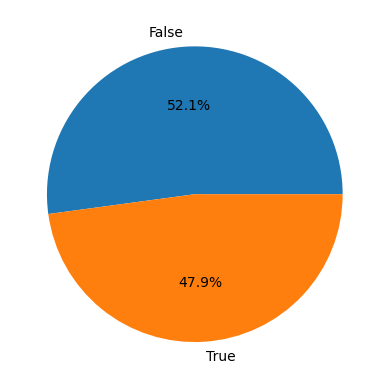

In [5]:
# checking is our classes divided equally?
total=health_data["Target"].value_counts()
plt.pie(total,autopct="%1.1f%%",labels=["False","True"])

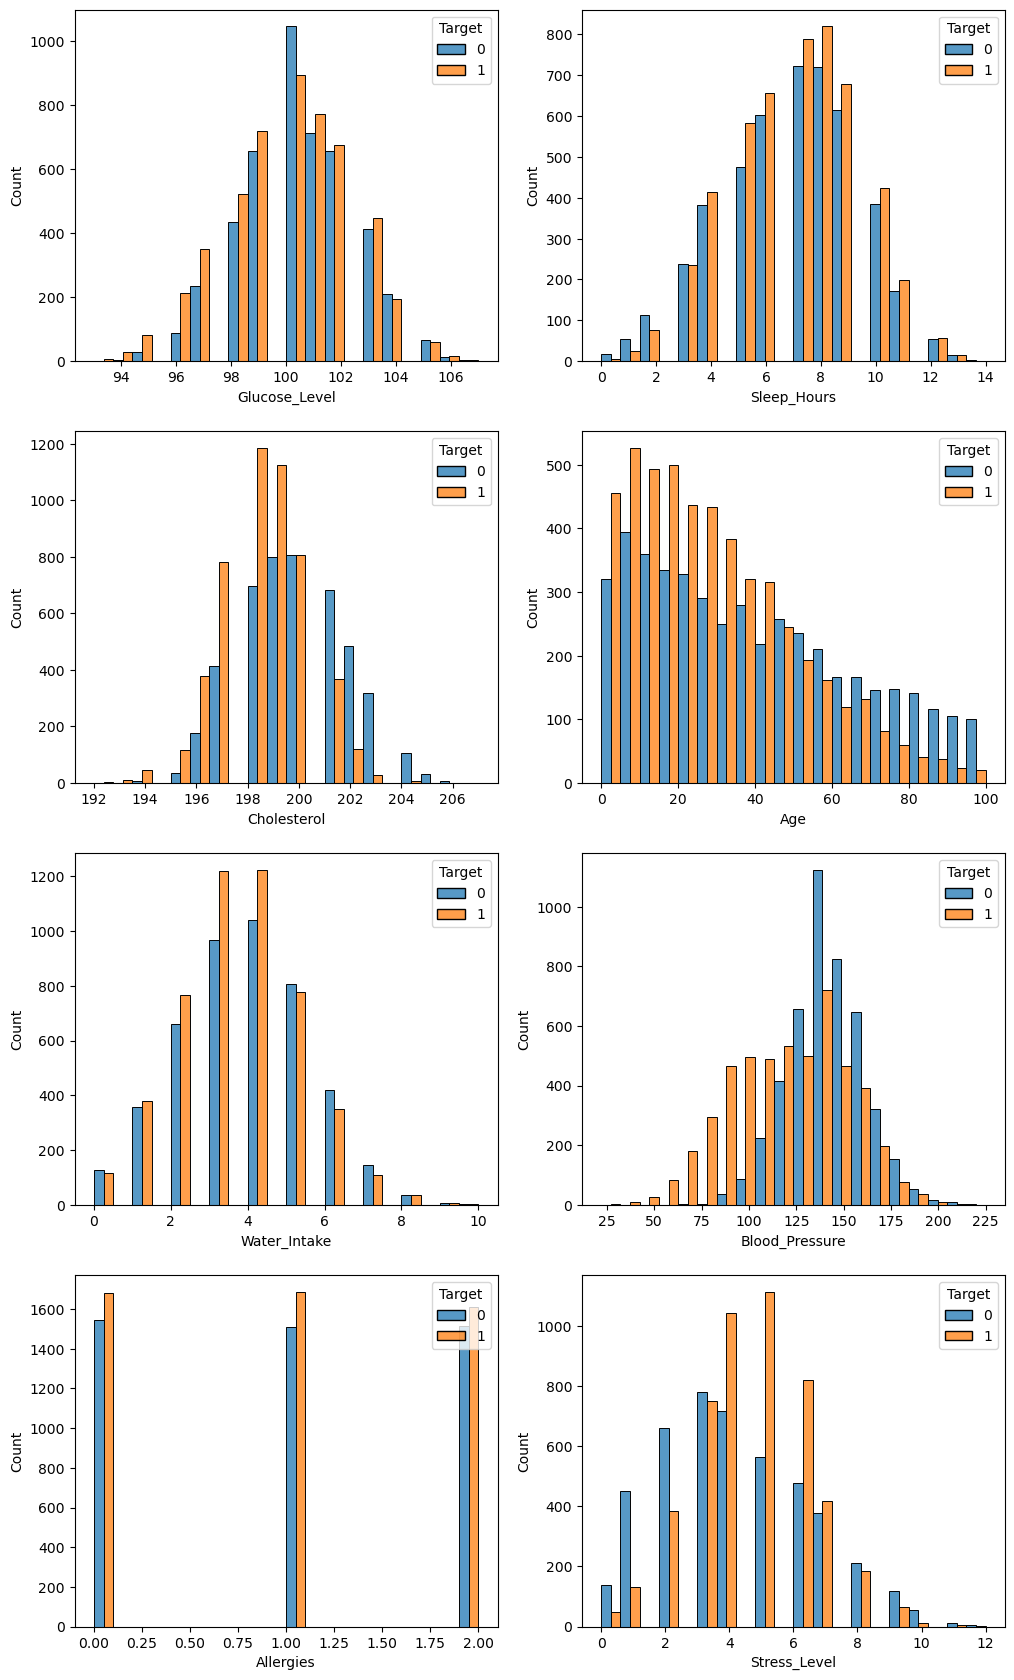

In [6]:
fig,ax=plt.subplots(4,2,figsize=(12,21))

sns.histplot(ax=ax[0,0],data=health_data,x="Glucose_Level",bins=20,hue="Target",multiple="dodge")
sns.histplot(ax=ax[0,1],data=health_data,x="Sleep_Hours",bins=20,hue="Target",multiple="dodge")
sns.histplot(ax=ax[1,0],data=health_data,x="Cholesterol",bins=20,hue="Target",multiple="dodge")
sns.histplot(ax=ax[1,1],data=health_data,x="Age",bins=20,hue="Target",multiple="dodge")
sns.histplot(ax=ax[2,0],data=health_data,x="Water_Intake",bins=20,hue="Target",multiple="dodge")
sns.histplot(ax=ax[2,1],data=health_data,x="Blood_Pressure",bins=20,hue="Target",multiple="dodge")
sns.histplot(ax=ax[3,0],data=health_data,x="Allergies",bins=20,hue="Target",multiple="dodge")
sns.histplot(ax=ax[3,1],data=health_data,x="Stress_Level",bins=20,hue="Target",multiple="dodge")

plt.show()

<Axes: xlabel='MedicalHistory', ylabel='Count'>

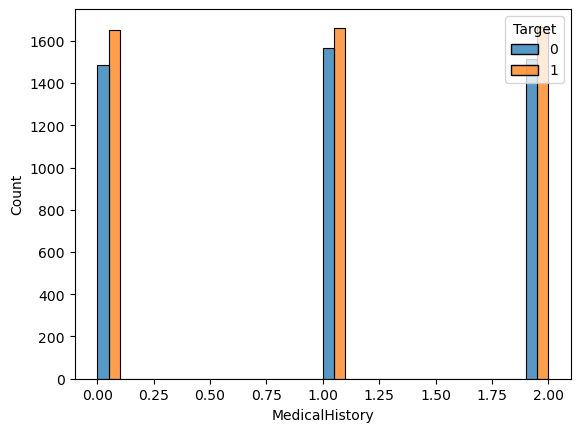

In [7]:
sns.histplot(data=health_data,x="MedicalHistory",hue="Target",bins=20,multiple="dodge")

<Axes: xlabel='Alcohol', ylabel='Target'>

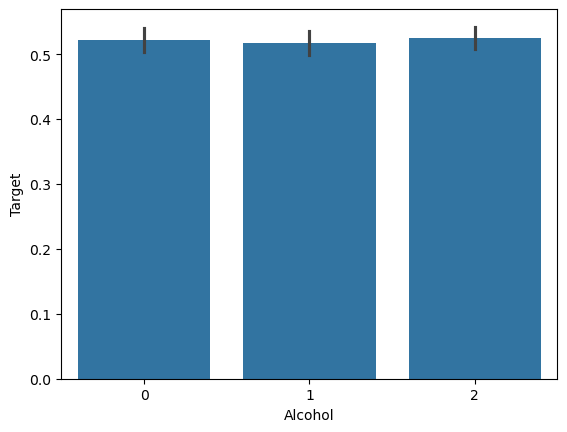

In [8]:
sns.barplot(data=health_data,x="Alcohol",y="Target")

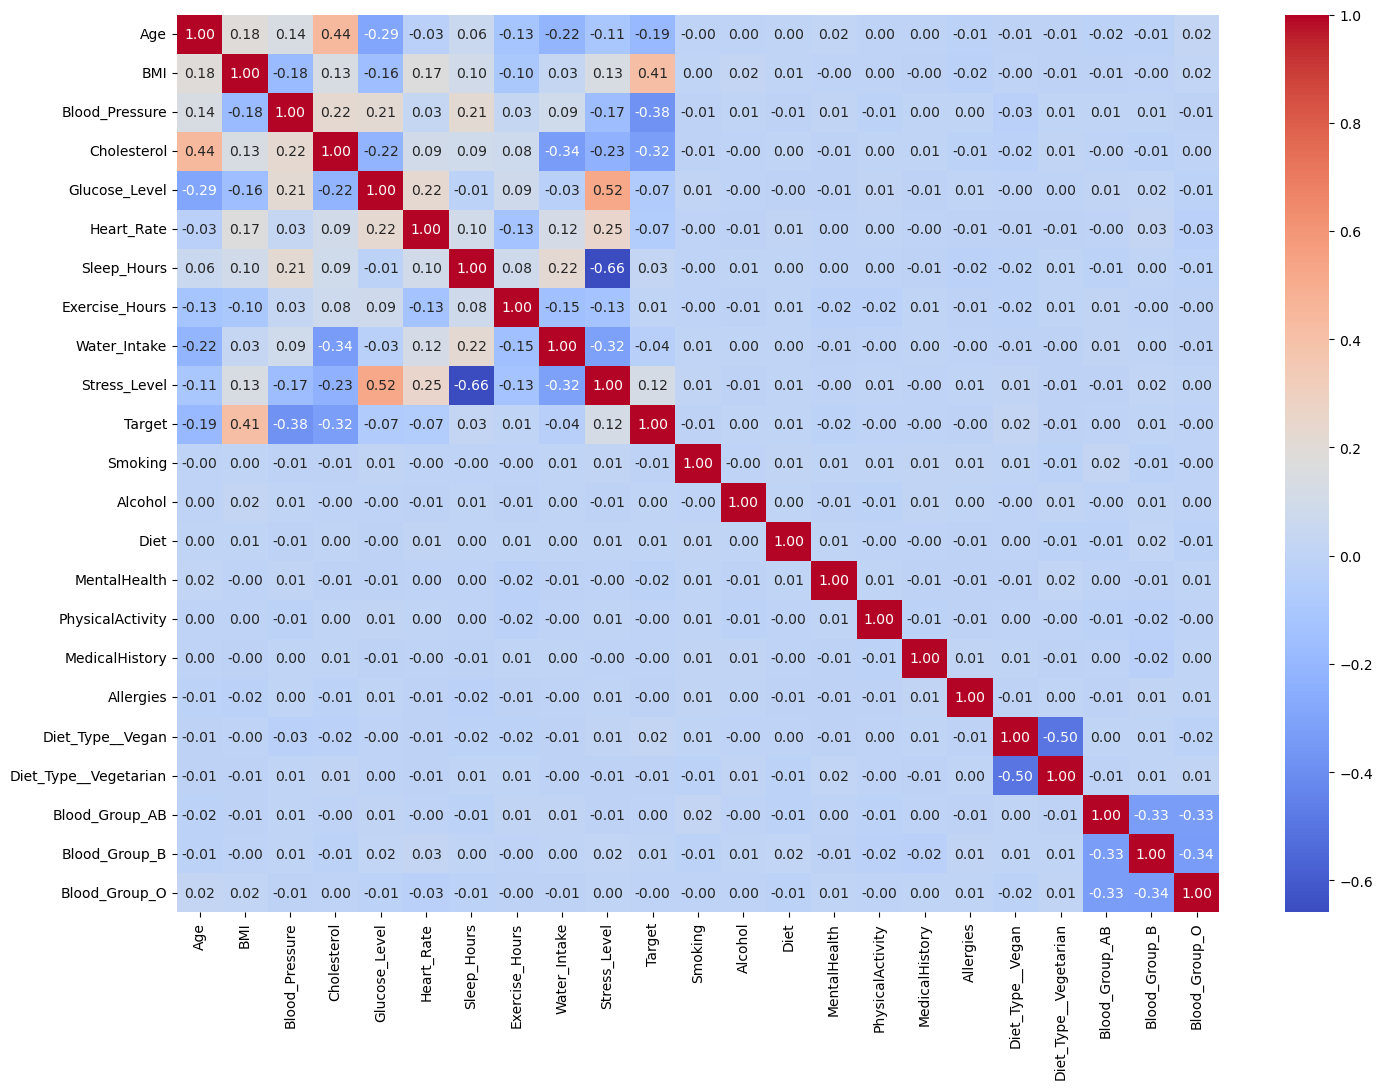

In [9]:
# correlation heatmap

num_col=health_data.select_dtypes(include="number")

corr_matrix=num_col.corr()

plt.figure(figsize=(15,11))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.tight_layout()
plt.show()

# Feature Engineering

In [10]:
health_data["BMI"]=health_data["BMI"]**2
health_data["Blood_Pressure"]=health_data["Blood_Pressure"]**2
health_data["Cholesterol"]=health_data["Cholesterol"]**2
health_data["Age"]=health_data["Age"]**2

In [11]:
health_data.info()
health_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,4.0,676.0,12321.0,39204.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,0,1,1,0,0
1,64.0,576.0,14641.0,39601.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,0,0,1,0,0
2,6561.0,729.0,21609.0,41209.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,1,0,0,0,0
3,625.0,441.0,22500.0,39601.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,1,0,0,1,0
4,576.0,676.0,21316.0,40804.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,0,1,0,1,0


# Train_Test_Split

In [12]:
X=health_data.drop(columns=["Target"])
y=health_data["Target"]

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [14]:
#scaling

from sklearn.preprocessing import StandardScaler


scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [15]:
X_train_scaled

array([[-0.71887175, -0.37004696, -1.18985808, ..., -0.5691369 ,
        -0.58405186, -0.58042385],
       [ 1.91760684,  0.14429786, -0.12457205, ...,  1.7570465 ,
        -0.58405186, -0.58042385],
       [-0.79210727,  0.67881307,  0.62927674, ...,  1.7570465 ,
        -0.58405186, -0.58042385],
       ...,
       [-0.70651326, -0.37004696, -0.5477854 , ..., -0.5691369 ,
        -0.58405186,  1.7228789 ],
       [-0.63098913,  0.67881307, -0.16140413, ..., -0.5691369 ,
        -0.58405186,  1.7228789 ],
       [-0.77974877, -0.37004696,  0.84472305, ...,  1.7570465 ,
        -0.58405186, -0.58042385]])

# Model Training

##  Target Variable & Classification Framing

The target variable in this dataset represents the overall health status of an individual 
and is categorized into two classes:

- **Healthy (0)**
- **Unhealthy (1)**

In this project, **Unhealthy (1)** is treated as the **positive class**.  
This framing aligns with standard healthcare risk analysis, where the primary objective 
is to correctly identify individuals who may be at higher health risk.

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,recall_score,confusion_matrix

In [21]:
# logistic model
LRModel=LogisticRegression(max_iter=1000)
LRModel.fit(X_train_scaled,y_train)
y_pred=LRModel.predict(X_test_scaled)
y_prd_train=LRModel.predict(X_train_scaled)
print("recall_score",recall_score(y_test,y_pred))
print("classification_report \n",classification_report(y_test,y_pred))

recall_score 0.8455445544554455
classification_report 
               precision    recall  f1-score   support

           0       0.82      0.81      0.81       900
           1       0.83      0.85      0.84      1010

    accuracy                           0.83      1910
   macro avg       0.83      0.83      0.83      1910
weighted avg       0.83      0.83      0.83      1910



Evaluation Metric Selection
In healthcare-related classification problems, different evaluation metrics capture different types of risk.

Since Unhealthy (1) is treated as the positive class, the most critical error to avoid is a False Negative — classifying an unhealthy individual as healthy.

Missing unhealthy individuals can:

Lead to incorrect eligibility decisions
Skew clinical trial results
Delay necessary medical attention
Therefore, Recall is prioritized as the primary evaluation metric in this project, as it directly measures the model’s ability to correctly identify unhealthy individuals.

Other metrics such as Precision and F1-score are also reported to provide a balanced performance overview.

In [22]:
#SVM model
modelsvc=SVC(C= 1,kernel= "rbf")
modelsvc.fit(X_train_scaled,y_train)

y_pred=modelsvc.predict(X_test_scaled)
y_prd_train=modelsvc.predict(X_train_scaled)

print("recall_score",recall_score(y_test,y_pred))
print("classification_report\n",classification_report(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

recall_score 0.9465346534653465
classification_report
               precision    recall  f1-score   support

           0       0.94      0.92      0.93       900
           1       0.93      0.95      0.94      1010

    accuracy                           0.93      1910
   macro avg       0.93      0.93      0.93      1910
weighted avg       0.93      0.93      0.93      1910

confusion_matrix [[829  71]
 [ 54 956]]


## Confusion Matrix Interpretation

The confusion matrix provides a detailed view of the model’s classification behavior:

- **True Positives (TP):** Unhealthy individuals correctly identified as unhealthy  
- **True Negatives (TN):** Healthy individuals correctly identified as healthy  

- **False Positives (FP):** Healthy individuals incorrectly classified as unhealthy  
  - This may cause unnecessary exclusion from trials but is comparatively safer.

- **False Negatives (FN):** Unhealthy individuals incorrectly classified as healthy  
  - This is the most critical error, as it may lead to high-risk individuals being 
    incorrectly considered eligible.

Given the healthcare context, minimizing **False Negatives** is prioritized, 
which further supports the choice of **Recall** as the primary metric.


In [23]:
# DecisionTree model
modelDT=DecisionTreeClassifier(max_depth= 8, min_samples_split= 2)
modelDT.fit(X_train_scaled,y_train)

y_pred=modelDT.predict(X_test_scaled)
y_prd_train=modelDT.predict(X_train_scaled)

print("recall_score",recall_score(y_test,y_pred))
print("classification_report\n",classification_report(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

recall_score 0.898019801980198
classification_report
               precision    recall  f1-score   support

           0       0.88      0.88      0.88       900
           1       0.89      0.90      0.90      1010

    accuracy                           0.89      1910
   macro avg       0.89      0.89      0.89      1910
weighted avg       0.89      0.89      0.89      1910

confusion_matrix [[792 108]
 [103 907]]


# Hyperparameter Tunning

In [26]:
from sklearn.model_selection import GridSearchCV

In [27]:
#knn
model=KNeighborsClassifier()

param_grid={"n_neighbors":[3,5,7,9,11]}

GSV=GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="recall"
)

GSV.fit(X_train_scaled,y_train)

print("best params",GSV.best_params_)

best params {'n_neighbors': 11}


In [32]:
modelknn=KNeighborsClassifier(n_neighbors=11)
modelknn.fit(X_train_scaled,y_train)

y_pred=modelknn.predict(X_test_scaled)
y_prd_train=modelknn.predict(X_train_scaled)


print("classification_report\n",classification_report(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

classification_report
               precision    recall  f1-score   support

           0       0.88      0.87      0.88       900
           1       0.89      0.90      0.89      1010

    accuracy                           0.89      1910
   macro avg       0.89      0.89      0.89      1910
weighted avg       0.89      0.89      0.89      1910

confusion_matrix [[784 116]
 [102 908]]


In [33]:
#Gausian naive bayes

modelnb=GaussianNB()
modelnb.fit(X_train_scaled,y_train)

y_pred=modelnb.predict(X_test_scaled)
y_prd_train=modelnb.predict(X_train_scaled)


print("classification_report\n",classification_report(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

classification_report
               precision    recall  f1-score   support

           0       0.81      0.77      0.79       900
           1       0.80      0.84      0.82      1010

    accuracy                           0.81      1910
   macro avg       0.81      0.80      0.81      1910
weighted avg       0.81      0.81      0.81      1910

confusion_matrix [[695 205]
 [164 846]]


# Bagging


In [37]:
from sklearn.ensemble import BaggingClassifier

model=SVC()

Bcls=BaggingClassifier(estimator=model,n_estimators=51,oob_score=True,random_state=42)

Bcls.fit(X_train_scaled,y_train)

print("recall_score",recall_score(y_test,y_pred))
print("training_oob_score",Bcls.oob_score_)
print("confusion_matrix",confusion_matrix(y_test,y_pred))

recall_score 0.8376237623762376
training_oob_score 0.9285246760047127
confusion_matrix [[695 205]
 [164 846]]


# Random Forest

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=101,oob_score=True,random_state=42)

rf.fit(X_train_scaled,y_train)

y_pred=rf.predict(X_test_scaled)


print("classification_report\n",classification_report(y_test,y_pred))
print("oob_score",rf.oob_score_)
print("confusion_matrix",confusion_matrix(y_test,y_pred))

classification_report
               precision    recall  f1-score   support

           0       0.93      0.94      0.94       900
           1       0.95      0.94      0.94      1010

    accuracy                           0.94      1910
   macro avg       0.94      0.94      0.94      1910
weighted avg       0.94      0.94      0.94      1910

oob_score 0.935200942531745
confusion_matrix [[846  54]
 [ 61 949]]


# Boosting

In [46]:
from sklearn.ensemble import GradientBoostingClassifier

gbc=GradientBoostingClassifier(n_estimators=201,random_state=42)


gbc.fit(X_train_scaled,y_train)

y_pred=gbc.predict(X_test_scaled)
y_prd_train=gbc.predict(X_train_scaled)

print("classification_report\n",classification_report(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

classification_report
               precision    recall  f1-score   support

           0       0.93      0.93      0.93       900
           1       0.93      0.93      0.93      1010

    accuracy                           0.93      1910
   macro avg       0.93      0.93      0.93      1910
weighted avg       0.93      0.93      0.93      1910

confusion_matrix [[834  66]
 [ 66 944]]


# Ada boosting

In [40]:
from sklearn.ensemble import AdaBoostClassifier

In [48]:
model=SVC()
abc=AdaBoostClassifier(estimator=model,n_estimators=101)
abc.fit(X_train_scaled,y_train)

y_pred=abc.predict(X_test_scaled)
y_prd_train=abc.predict(X_train_scaled)

print("classification_report\n",classification_report(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

classification_report
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       900
           1       0.53      1.00      0.69      1010

    accuracy                           0.53      1910
   macro avg       0.26      0.50      0.35      1910
weighted avg       0.28      0.53      0.37      1910

confusion_matrix [[   0  900]
 [   0 1010]]


C:\Users\91917\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\91917\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\91917\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##  AdaBoost Model Analysis and Rejection

Although the AdaBoost classifier achieved a recall score of 1.00 for the Unhealthy class, 
further analysis revealed that this performance was misleading.

The confusion matrix showed that the model classified **all individuals as Unhealthy**, 
resulting in:
- Zero predictions for the Healthy class
- Recall of 0.00 for Healthy individuals
- Very low precision and poor class discrimination

This behavior indicates that the model lacks practical decision-making capability and 
does not meaningfully differentiate between health conditions.

Therefore, despite its perfect recall, AdaBoost was **not selected** as the final model 
due to its poor real-world usability.

# Stacking

In [43]:
from sklearn.ensemble import StackingClassifier

In [47]:
svc=SVC()
dtc=DecisionTreeClassifier(max_depth= 8, min_samples_split= 2)
knn=KNeighborsClassifier(n_neighbors=11)
st=StackingClassifier(estimators=[("svc",svc),
          ("DT",dtc),
          ("knn",knn)],cv=5)

st.fit(X_train_scaled,y_train)

y_pred=st.predict(X_test_scaled)
y_prd_train=st.predict(X_train_scaled)

print("classification_report\n",classification_report(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

classification_report
               precision    recall  f1-score   support

           0       0.94      0.93      0.93       900
           1       0.94      0.94      0.94      1010

    accuracy                           0.94      1910
   macro avg       0.94      0.94      0.94      1910
weighted avg       0.94      0.94      0.94      1910

confusion_matrix [[837  63]
 [ 56 954]]


## Model Performance Comparison

The following table summarizes the performance of all trained models, with special focus on recall for unhealthy individuals.

In [50]:
model_results

,Model,Precision (Unhealthy),Recall (Unhealthy),F1-score (Unhealthy),Accuracy
0,Random Forest,0.95,0.94,0.94,0.94
1,Boosting,0.93,0.93,0.93,0.93
2,Stacking,0.94,0.94,0.94,0.94


## Final Model Selection

In healthcare applications, recall for unhealthy individuals is a critical metric, as failing to identify sick individuals can lead to severe consequences.

Among all evaluated models, Random Forest achieved a high recall of 94% for unhealthy individuals while also maintaining strong precision and overall balanced performance. Although ensemble approaches such as Boosting and Stacking showed comparable results, Random Forest was selected due to its robustness, interpretability, and consistent performance.

Therefore, Random Forest was chosen as the final model for this healthcare classification task.


## Conclusion

This project demonstrates the application of machine learning techniques to a real-world healthcare classification problem. By evaluating multiple models and carefully selecting appropriate performance metrics, a robust and reliable classifier was developed.

The Random Forest model provided the best balance between recall and precision for identifying unhealthy individuals, making it suitable for healthcare decision-support systems such as clinical trial selection and population risk stratification.
